In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.4 MB/s eta 0:00:00


In [2]:
import yaml

data_yaml = {
    'train': '/kaggle/input/smoke-fire-detection-yolo/data/train/images',
    'val': '/kaggle/input/smoke-fire-detection-yolo/data/val/images',
    'test': '/kaggle/input/smoke-fire-detection-yolo/data/test/images',
    'nc': 2,
    'names': ['fire', 'smoke'] # Double check if your dataset uses these exact names
}

with open('mysettings.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

In [3]:
import PIL.Image as Image
import os

path = '/kaggle/input/smoke-fire-detection-yolo/data/train/images'
imgs = os.listdir(path)[:5] # Check first 5

for img_name in imgs:
    try:
        img = Image.open(os.path.join(path, img_name))
        img.verify() 
        print(f"{img_name} is healthy")
    except Exception as e:
        print(f"{img_name} is CORRUPT: {e}")

WEB09284.jpg is healthy
WEB02703.jpg is healthy
WEB02722.jpg is healthy
AoF02394.jpg is healthy
WEB02906.jpg is healthy


In [13]:
from ultralytics import YOLO

# Load a pre-trained model
model = YOLO('yolov8n.pt') 

# Train - it will automatically validate your images and labels
results = model.train(
    data='mysettings.yaml', 
    epochs=5, 
    imgsz=640, 
    plots=True
)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mysettings.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12

Loading results from: runs/detect/train4/
Could not find F1_curve.png in runs/detect/train4/


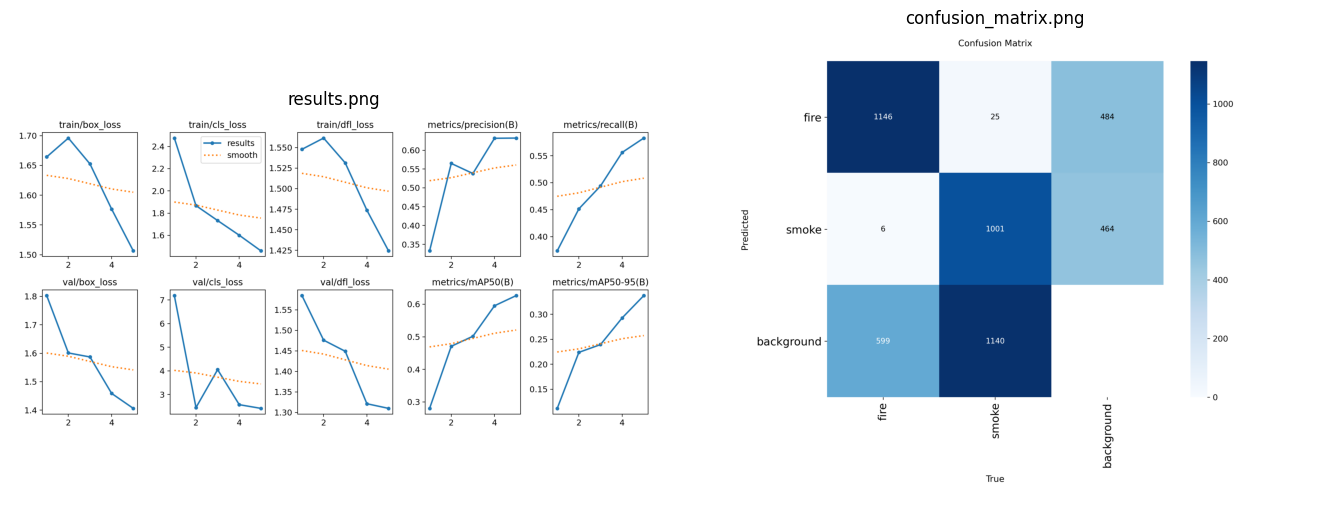

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import glob

# This finds the newest 'train' folder automatically
all_runs = glob.glob('runs/detect/train*')
if all_runs:
    results_path = max(all_runs, key=os.path.getmtime) + '/'
    print(f"Loading results from: {results_path}")

    plots = ['results.png', 'confusion_matrix.png', 'F1_curve.png']
    plt.figure(figsize=(20, 10))

    for i, plot in enumerate(plots):
        full_path = os.path.join(results_path, plot)
        if os.path.exists(full_path):
            plt.subplot(1, 3, i+1)
            img = mpimg.imread(full_path)
            plt.imshow(img)
            plt.axis('off')
            plt.title(plot)
        else:
            print(f"Could not find {plot} in {results_path}")
    
    plt.tight_layout()
    plt.show() # Forces the notebook to render the plot
else:
    print("No training runs found yet. Did the training finish?")

In [15]:
# Test on a single image from the test set
results = model.predict(source='/kaggle/input/smoke-fire-detection-yolo/data/test/images', save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06723.jpg: 384x640 (no detections), 7.2ms
image 2/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06724.jpg: 352x640 (no detections), 7.0ms
image 3/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06725.jpg: 384x640 (no detections), 6.9ms
image 4/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06726.jpg: 384x640 (no detections), 6.3m

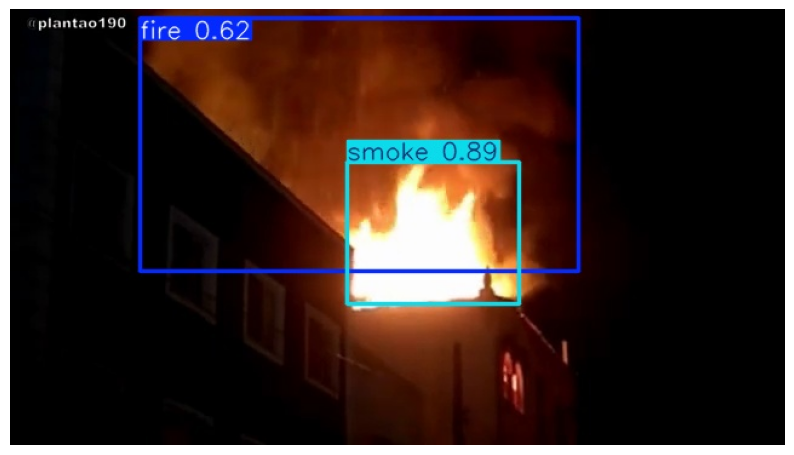

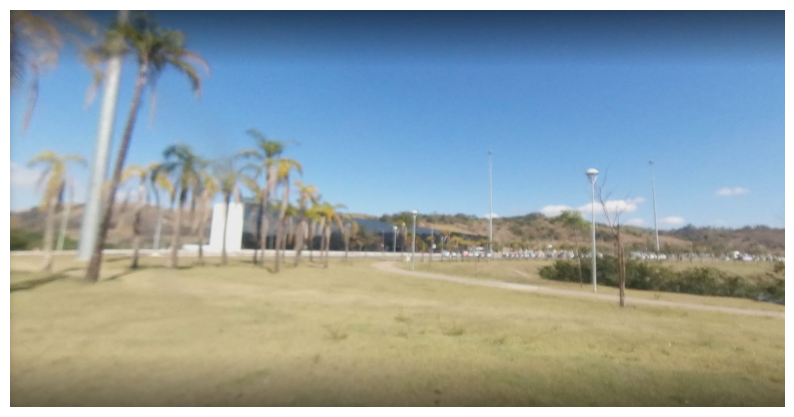

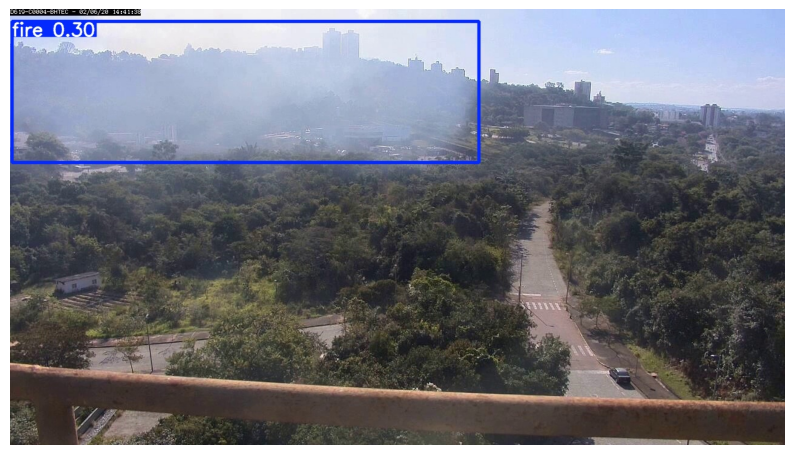

In [17]:
import glob
prediction_images = glob.glob('runs/detect/predict/*.jpg')[0:3]

for img_path in prediction_images:
    plt.figure(figsize=(10, 10))
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()